Import libiraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (
    train_test_split,
    GridSearchCV
)

from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import joblib

sns.set_style("whitegrid")

Upload dataset

In [2]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/353022_6a218449cbff6_1780581449.csv")

df.head()

,Customer_ID,Age,Gender,Monthly_Charges,Tenure_Months,Internet_Service,Contract_Type,Support_Calls,Payment_Method,Churn
0,10001,56,Male,85.92,55,Cable,Two Year,7,Credit Card,Yes
1,10002,69,Female,44.43,62,DSL,One Year,7,Cash,No
2,10003,46,Male,30.01,55,Fiber,One Year,2,Cash,No
3,10004,32,Male,110.50,36,DSL,Month-to-Month,3,Cash,Yes
4,10005,60,Female,69.76,24,Cable,Two Year,1,Credit Card,No


Data Understanding

In [3]:
print("Dataset Shape:", df.shape)

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nBasic Statistics:")
display(df.describe())

Dataset Shape: (3000, 10)

Data Types:
Customer_ID           int64
Age                   int64
Gender               object
Monthly_Charges     float64
Tenure_Months         int64
Internet_Service     object
Contract_Type        object
Support_Calls         int64
Payment_Method       object
Churn                object
dtype: object

Missing Values:
Customer_ID         0
Age                 0
Gender              0
Monthly_Charges     0
Tenure_Months       0
Internet_Service    0
Contract_Type       0
Support_Calls       0
Payment_Method      0
Churn               0
dtype: int64

Basic Statistics:


,Customer_ID,Age,Monthly_Charges,Tenure_Months,Support_Calls
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,11500.500000,43.563000,84.244283,36.221667,4.951000
std,866.169729,14.941791,37.455665,20.585054,3.165218
min,10001.000000,18.000000,20.000000,1.000000,0.000000
25%,10750.750000,31.000000,51.647500,18.000000,2.000000
50%,11500.500000,44.000000,83.445000,36.000000,5.000000
75%,12250.250000,56.000000,116.460000,54.000000,8.000000
max,13000.000000,69.000000,149.940000,71.000000,10.000000


Data Cleaning

In [4]:
print("Duplicates:", df.duplicated().sum())

df.drop_duplicates(inplace=True)

print("New Shape:", df.shape)

Duplicates: 0
New Shape: (3000, 10)


Data Preprocessing

In [5]:
df.drop("Customer_ID", axis=1, inplace=True)

In [6]:
categorical_cols = df.select_dtypes(include='object').columns

print(categorical_cols)

Index(['Gender', 'Internet_Service', 'Contract_Type', 'Payment_Method',
       'Churn'],
      dtype='object')


In [7]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in categorical_cols:
    df[col] = encoder.fit_transform(df[col])

df.head()

,Age,Gender,Monthly_Charges,Tenure_Months,Internet_Service,Contract_Type,Support_Calls,Payment_Method,Churn
0,56,1,85.92,55,0,2,7,2,1
1,69,0,44.43,62,1,1,7,1,0
2,46,1,30.01,55,2,1,2,1,0
3,32,1,110.50,36,1,0,3,1,1
4,60,0,69.76,24,0,2,1,2,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               3000 non-null   int64  
 1   Gender            3000 non-null   int64  
 2   Monthly_Charges   3000 non-null   float64
 3   Tenure_Months     3000 non-null   int64  
 4   Internet_Service  3000 non-null   int64  
 5   Contract_Type     3000 non-null   int64  
 6   Support_Calls     3000 non-null   int64  
 7   Payment_Method    3000 non-null   int64  
 8   Churn             3000 non-null   int64  
dtypes: float64(1), int64(8)
memory usage: 211.1 KB


In [9]:
X = df.drop("Churn", axis=1)

y = df["Churn"]

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape :", X_test.shape)

Training Shape: (2400, 8)
Testing Shape : (600, 8)


Exploratory Data Analysis

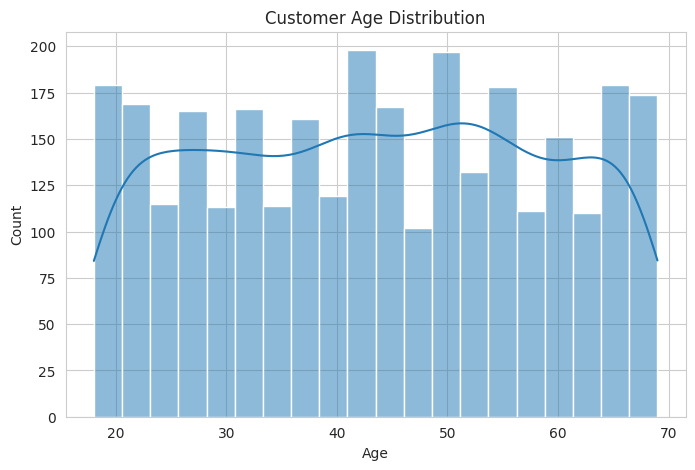

In [11]:
#Age distribution
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)

plt.title("Customer Age Distribution")
plt.show()

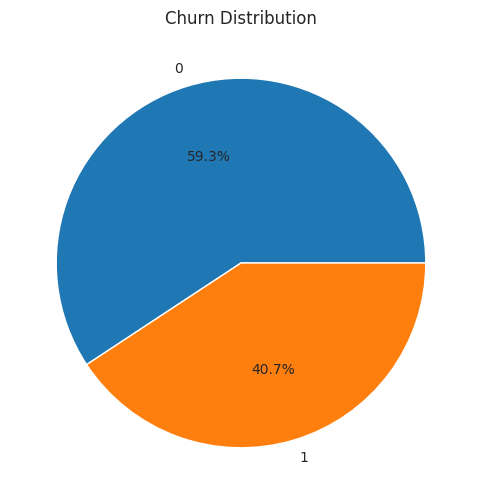

In [15]:
#Churn Distribution
plt.figure(figsize=(6,6))

df["Churn"].value_counts().plot(
    kind="pie",
    autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Churn Distribution")

plt.show()

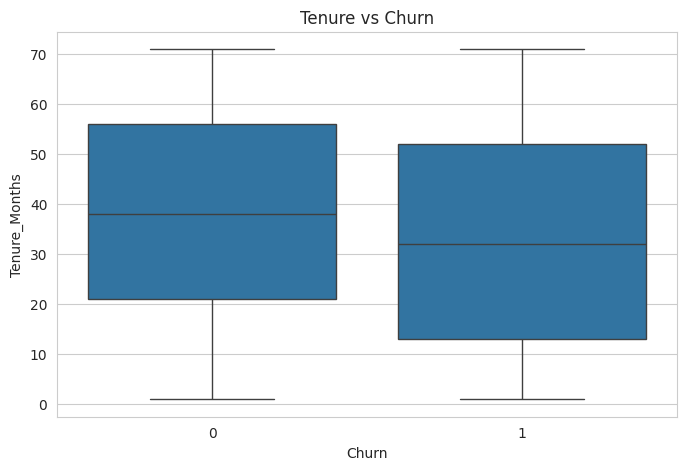

In [14]:
#Tenure vs Churn
plt.figure(figsize=(8,5))

sns.boxplot(
    x="Churn",
    y="Tenure_Months",
    data=df
)

plt.title("Tenure vs Churn")

plt.show()

Feature Engineering

In [16]:
df["Customer_Age_Group"] = pd.cut(
    df["Age"],
    bins=[18,30,45,60,100],
    labels=[
        "Young",
        "Adult",
        "Middle_Age",
        "Senior"
    ]
)

df["Charge_Tenure_Ratio"] = (
    df["Monthly_Charges"] /
    (df["Tenure_Months"] + 1)
)

df.head()

,Age,Gender,Monthly_Charges,Tenure_Months,Internet_Service,Contract_Type,Support_Calls,Payment_Method,Churn,Customer_Age_Group,Charge_Tenure_Ratio
0,56,1,85.92,55,0,2,7,2,1,Middle_Age,1.534286
1,69,0,44.43,62,1,1,7,1,0,Senior,0.705238
2,46,1,30.01,55,2,1,2,1,0,Middle_Age,0.535893
3,32,1,110.50,36,1,0,3,1,1,Adult,2.986486
4,60,0,69.76,24,0,2,1,2,0,Middle_Age,2.790400


In [18]:
encoder = LabelEncoder()

for col in df.columns:

    if df[col].dtype == "object":
        df[col] = encoder.fit_transform(df[col])

df["Customer_Age_Group"] = (
    LabelEncoder()
    .fit_transform(df["Customer_Age_Group"])
)

Model Building and Evaluation

In [19]:
def evaluate_model(model, X_test, y_test):

    predictions = model.predict(X_test)

    accuracy = accuracy_score(y_test, predictions)
    precision = precision_score(y_test, predictions)
    recall = recall_score(y_test, predictions)
    f1 = f1_score(y_test, predictions)

    print("Accuracy :", accuracy)
    print("Precision:", precision)
    print("Recall   :", recall)
    print("F1 Score :", f1)

    print("\nClassification Report")

    print(classification_report(
        y_test,
        predictions
    ))

    cm = confusion_matrix(
        y_test,
        predictions
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d"
    )

    plt.title("Confusion Matrix")
    plt.show()

    return accuracy, precision, recall, f1

Accuracy : 0.7466666666666667
Precision: 0.7254901960784313
Recall   : 0.6065573770491803
F1 Score : 0.6607142857142857

Classification Report
              precision    recall  f1-score   support

           0       0.76      0.84      0.80       356
           1       0.73      0.61      0.66       244

    accuracy                           0.75       600
   macro avg       0.74      0.72      0.73       600
weighted avg       0.74      0.75      0.74       600



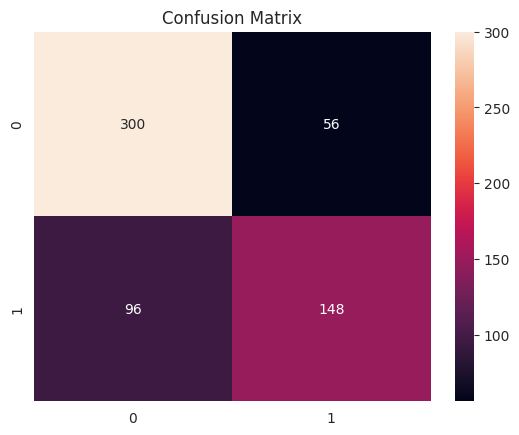

In [20]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train,
    y_train
)

log_results = evaluate_model(
    log_model,
    X_test,
    y_test
)

Accuracy : 0.7983333333333333
Precision: 0.7808219178082192
Recall   : 0.7008196721311475
F1 Score : 0.7386609071274298

Classification Report
              precision    recall  f1-score   support

           0       0.81      0.87      0.84       356
           1       0.78      0.70      0.74       244

    accuracy                           0.80       600
   macro avg       0.79      0.78      0.79       600
weighted avg       0.80      0.80      0.80       600



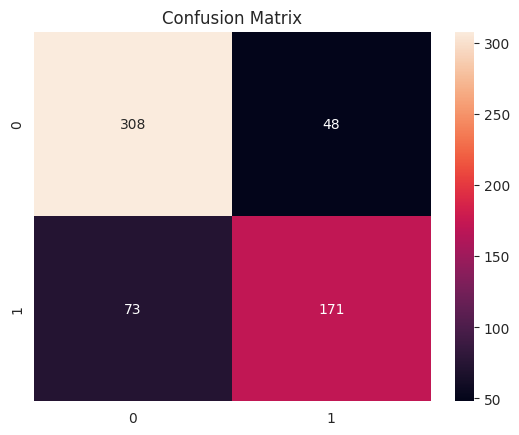

In [21]:
rf_model = RandomForestClassifier(
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

rf_results = evaluate_model(
    rf_model,
    X_test,
    y_test
)

Model Comparison

In [23]:
comparison = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Random Forest"
    ],

    "Accuracy":[
        log_results[0],
        rf_results[0]
    ],

    "Precision":[
        log_results[1],
        rf_results[1]
    ],

    "Recall":[
        log_results[2],
        rf_results[2]
    ],

    "F1 Score":[
        log_results[3],
        rf_results[3]
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.746667,0.725490,0.606557,0.660714
1,Random Forest,0.798333,0.780822,0.700820,0.738661


Hyperparameter Tuning

In [24]:
param_grid = {

    "n_estimators":[100,200,300],

    "max_depth":[
        5,
        10,
        15,
        None
    ],

    "min_samples_split":[
        2,
        5,
        10
    ]
}

In [25]:
grid_search = GridSearchCV(

    estimator=RandomForestClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="f1",

    n_jobs=-1
)

grid_search.fit(
    X_train,
    y_train
)

print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 300}


Accuracy : 0.8083333333333333
Precision: 0.7918552036199095
Recall   : 0.7172131147540983
F1 Score : 0.7526881720430108

Classification Report
              precision    recall  f1-score   support

           0       0.82      0.87      0.84       356
           1       0.79      0.72      0.75       244

    accuracy                           0.81       600
   macro avg       0.80      0.79      0.80       600
weighted avg       0.81      0.81      0.81       600



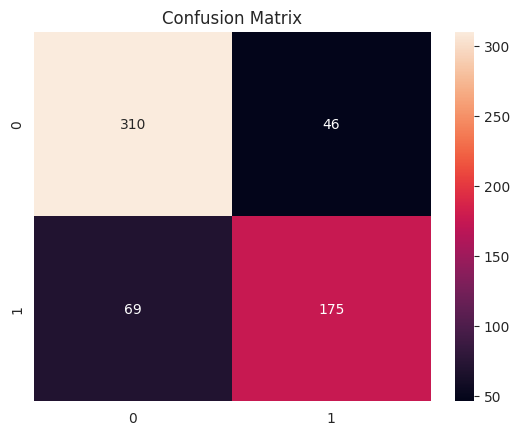

In [26]:
best_model = grid_search.best_estimator_

best_results = evaluate_model(
    best_model,
    X_test,
    y_test
)

In [27]:
joblib.dump(
    best_model,
    "best_model.pkl"
)

print("Model Saved Successfully")

Model Saved Successfully
